In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
!pip uninstall -y datasets huggingface_hub pyarrow fsspec
!pip install datasets==2.21.0 huggingface_hub==0.24.6 pyarrow==16.1.0 fsspec==2024.5.0

In [ ]:
!pip install datasets==2.21.0

In [2]:
import datasets
import huggingface_hub
import pyarrow
import fsspec

print(datasets.__version__)
print(huggingface_hub.__version__)
print(pyarrow.__version__)
print(fsspec.__version__)

2.21.0
1.24.0
25.0.0
2024.5.0


In [ ]:
!pip install -U pip setuptools wheel
!pip install seqeval --no-build-isolation

In [70]:
!pip install transformers torch -q

# Libraries

In [92]:
import shutil
import os
import json
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Bidirectional
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from transformers import AutoTokenizer,AutoModelForTokenClassification,Trainer,TrainingArguments,DataCollatorForTokenClassification
from transformers import TrainingArguments, Trainer
import torch

# Load Dataset

In [3]:
# Dataset
local_path = "/kaggle/working/conll2003"
if os.path.exists(local_path):
    shutil.rmtree(local_path)
    print("Deleted")

print("Loaded from Hugging Face...")
dataset = load_dataset("eriktks/conll2003", trust_remote_code=True)

print("Done")

Loaded from Hugging Face...


Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Done


In [4]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})


# EDA

In [6]:
# Display dataset feature information
dataset["train"].features

{'id': Value(dtype='string', id=None),
 'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'pos_tags': Sequence(feature=ClassLabel(names=['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB'], id=None), length=-1, id=None),
 'chunk_tags': Sequence(feature=ClassLabel(names=['O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP', 'B-CONJP', 'I-CONJP', 'B-INTJ', 'I-INTJ', 'B-LST', 'I-LST', 'B-NP', 'I-NP', 'B-PP', 'I-PP', 'B-PRT', 'I-PRT', 'B-SBAR', 'I-SBAR', 'B-UCP', 'I-UCP', 'B-VP', 'I-VP'], id=None), length=-1, id=None),
 'ner_tags': Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC'], id=None), length=-1, id=None)}

In [7]:
# Display a sample text and its NER labels
sample = dataset["train"][0]

print(f"Tokens  : {sample["tokens"]}")
print(f"NER Tags: {sample["ner_tags"]}")

Tokens  : ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
NER Tags: [3, 0, 7, 0, 0, 0, 7, 0, 0]


In [8]:
# Retrieve NER label names
label_names = dataset["train"].features["ner_tags"].feature.names

label_names

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

In [10]:
# Display tokens with their NER labels
def show_sentence(example):

    for token, label in zip(
        example["tokens"],
        example["ner_tags"]
    ):
        print(token,"---->",label_names[label])

In [11]:
show_sentence(dataset["train"][0])

EU ----> B-ORG
rejects ----> O
German ----> B-MISC
call ----> O
to ----> O
boycott ----> O
British ----> B-MISC
lamb ----> O
. ----> O


In [12]:
# Show dataset split sizes
split_sizes = {
    split: len(dataset[split])
    for split in dataset
}

pd.DataFrame(
    split_sizes.items(),
    columns=["Split","Samples"]
)

,Split,Samples
0,train,14041
1,validation,3250
2,test,3453


In [13]:
# Collect all NER labels
all_labels=[]

for example in dataset["train"]:
    for label in example["ner_tags"]:
        all_labels.append(
            label_names[label]
        )

In [14]:
Counter(all_labels)

Counter({'B-ORG': 6321,
         'O': 169578,
         'B-MISC': 3438,
         'B-PER': 6600,
         'I-PER': 4528,
         'B-LOC': 7140,
         'I-ORG': 3704,
         'I-MISC': 1155,
         'I-LOC': 1157})

/tmp/ipykernel_655/2733935164.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


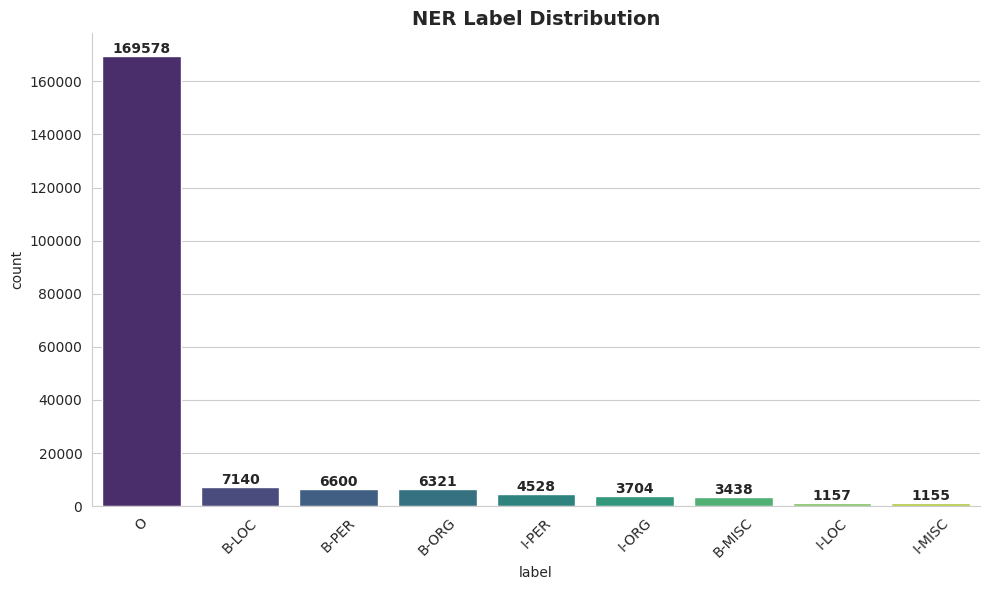

In [15]:
# Plot NER label distribution
label_counts = Counter(all_labels)

# Create DataFrame
label_df = pd.DataFrame({
    "label": list(label_counts.keys()),
    "count": list(label_counts.values())
}).sort_values("count", ascending=False)

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

ax = sns.barplot(data=label_df,x="label",y="count",palette="viridis")

plt.title("NER Label Distribution", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)

# Display values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

In [16]:
# Count named entities
entity_counter = Counter()

for label in all_labels:
    if label != "O":
        entity = label.split("-")[1]
        entity_counter[entity]+=1

entity_counter

Counter({'ORG': 10025, 'MISC': 4593, 'PER': 11128, 'LOC': 8297})

/tmp/ipykernel_655/3099286386.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


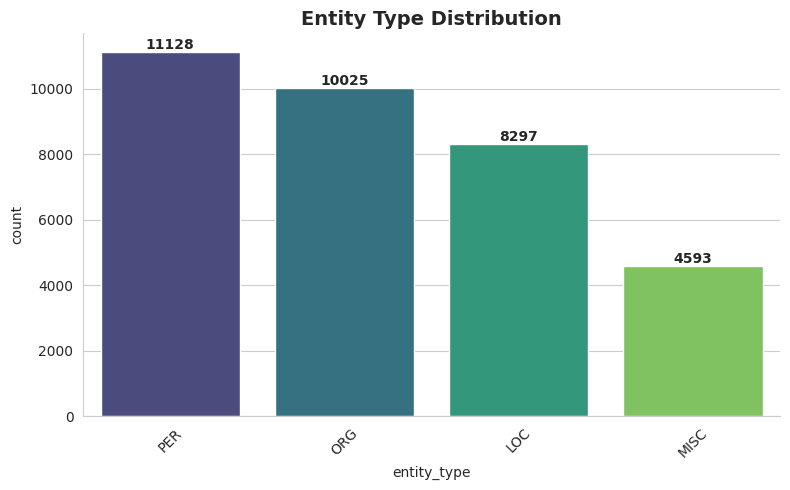

In [17]:
# Plot entity type distribution
entity_df = pd.DataFrame({
    "entity_type": list(entity_counter.keys()),
    "count": list(entity_counter.values())
}).sort_values("count", ascending=False)

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

ax = sns.barplot(data=entity_df,x="entity_type",y="count",palette="viridis")

plt.title("Entity Type Distribution",fontsize=14,fontweight="bold")
plt.xticks(rotation=45)

# Display values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

In [18]:
# Calculate sentence lengths
sentence_lengths=[]

for example in dataset["train"]:
    sentence_lengths.append(
        len(example["tokens"])
    )

In [19]:
avg_length = sum(sentence_lengths) / len(sentence_lengths)

print(f"Average sentence length: {avg_length:.2f} tokens")

Average sentence length: 14.50 tokens


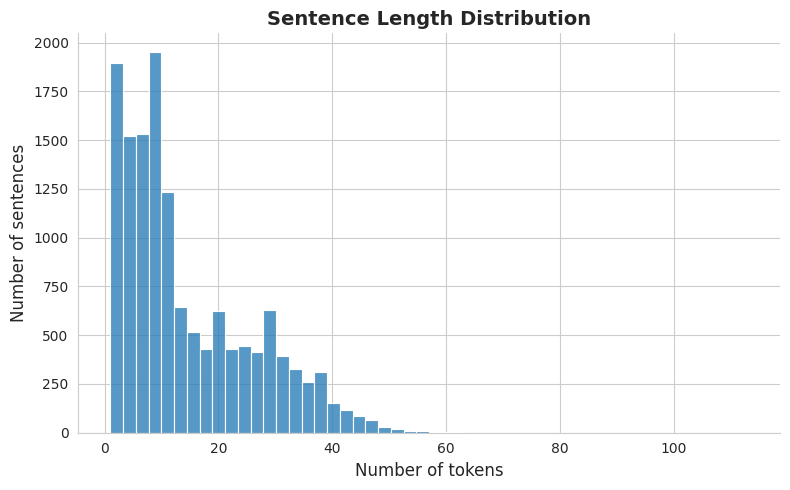

In [20]:
# Plot sentence length distribution
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

ax = sns.histplot(sentence_lengths,bins=50)

plt.title("Sentence Length Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Number of tokens",fontsize=12)
plt.ylabel("Number of sentences",fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

In [21]:
# Show the minimum sentence length
print(f"Minimum Length of the sentence: {min(sentence_lengths)}")

Minimum Length of the sentence: 1


In [22]:
# Show the maximum sentence length
print(f"Maximum Length of the sentence: {max(sentence_lengths)}")

Maximum Length of the sentence: 113


In [23]:
# Count word frequencies
words=[]

for example in dataset["train"]:
    words.extend(
        example["tokens"]
    )

word_freq = Counter(words)

In [24]:
word_freq.most_common(20)

[('.', 7374),
 (',', 7290),
 ('the', 7243),
 ('of', 3751),
 ('in', 3398),
 ('to', 3382),
 ('a', 2994),
 ('(', 2861),
 (')', 2861),
 ('and', 2838),
 ('"', 2178),
 ('on', 2040),
 ('said', 1846),
 ("'s", 1536),
 ('for', 1421),
 ('1', 1421),
 ('-', 1243),
 ('The', 1127),
 ('was', 1095),
 ('2', 973)]

In [25]:
# Calculate the ratio of entity tokens
total_tokens = 0
entity_tokens = 0

for example in dataset["train"]:
    total_tokens += len(example["tokens"])

    entity_tokens += sum(
        1 for x in example["ner_tags"]
        if x != 0
    )

print(f"The Ratio of Entity Tokens: {entity_tokens / total_tokens}")

The Ratio of Entity Tokens: 0.16718806017061108


# Data Preprocessing

## Label Encoding

In [26]:
# Display NER label mapping 
label_names = dataset["train"].features["ner_tags"].feature.names

for i, label in enumerate(label_names):
    print(i, "→", label)

0 → O
1 → B-PER
2 → I-PER
3 → B-ORG
4 → I-ORG
5 → B-LOC
6 → I-LOC
7 → B-MISC
8 → I-MISC


In [27]:
# Map IDs to labels
id2label = {i: label for i, label in enumerate(label_names)}

In [28]:
id2label[1]

'B-PER'

In [29]:
# Map labels to IDs
label2id = {label:i for i,label in enumerate(label_names)}

In [30]:
label2id["B-ORG"]

3

## Vocabulary Construction & Token Encoding

In [31]:
# Count the number of words repeated in the training data
word_counter = Counter()
for example in dataset["train"]:
    word_counter.update(example["tokens"])

# Only the 15,000 most frequently used words were taken
top_words = word_counter.most_common(15000)

# Creating a Word to ID conversion dictionary
word_to_id = {
    "<PAD>": 0,
    "<UNK>": 1
}

# Adding common words to the dictionary 
for i, (word, count) in enumerate(top_words):
    word_to_id[word] = i + 2

Vocab_size = len(word_to_id)
print(f"The vocabulary was successfully created. New size: {Vocab_size}")

# Encoding
def encode_tokens(tokens):
    return [word_to_id.get(word, word_to_id["<UNK>"]) for word in tokens]

sample = dataset["train"][0]
print(f"Tokens: {sample['tokens'][:5]}")
print(f"Encoded: {encode_tokens(sample['tokens'][:5])}")

The vocabulary was successfully created. New size: 15002
Tokens: ['EU', 'rejects', 'German', 'call', 'to']
Encoded: [958, 11984, 234, 763, 7]


## Dataset Preparation

In [32]:
# Prepare the dataset for training
def prepare_dataset(split):
    X = []
    y = []

    for example in dataset[split]:
        X.append(encode_tokens(example["tokens"]))

        y.append(example["ner_tags"])

    return X, y

In [33]:
X_train, y_train = prepare_dataset("train")

X_val, y_val = prepare_dataset("validation")

X_test, y_test = prepare_dataset("test")

In [34]:
print(f"Train samples: {len(X_train)}")
print(f"Val samples  : {len(X_val)}")
print(f"Test samples : {len(X_test)}")

Train samples: 14041
Val samples  : 3250
Test samples : 3453


In [35]:
# Sequence Length Analysis
lengths = [len(x) for x in X_train]

print("Sequence Length Statistics")
print("=" * 30)
print(f"Average Length : {np.mean(lengths):.2f}")
print(f"Maximum Length : {max(lengths)}")

Sequence Length Statistics
Average Length : 14.50
Maximum Length : 113


## Sequence Padding

In [36]:
# Analyze sequence lengths
Max_len = 113

X_train_pad = pad_sequences(X_train,maxlen=Max_len,padding="post",truncating="post")

X_val_pad = pad_sequences(X_val,maxlen=Max_len,padding="post",truncating="post")

X_test_pad = pad_sequences(X_test,maxlen=Max_len,padding="post",truncating="post")

In [37]:
# Pad label sequences
def pad_labels(labels, max_len):
    padded=[]

    for label in labels:
        label = label[:max_len]
        label += [-100] * (max_len - len(label))
        padded.append(label)

    return padded

In [38]:
y_train_pad = pad_labels(y_train,Max_len)

y_val_pad = pad_labels(y_val,Max_len)

y_test_pad = pad_labels(y_test,Max_len)

In [39]:
# Create tensor Dataset
X_train_pad = tf.constant(X_train_pad)

y_train_pad = tf.constant(y_train_pad)

I0000 00:00:1784494908.181785     655 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784494908.184569     655 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [40]:
# Create TensorFlow datasets for training, validation, and testing
Batch_size = 32

# Training Set
train_ds = tf.data.Dataset.from_tensor_slices((X_train_pad,y_train_pad))

train_ds = (
    train_ds
    .shuffle(1000)
    .batch(Batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation Set
val_ds = tf.data.Dataset.from_tensor_slices((X_val_pad,y_val_pad))

val_ds = (
    val_ds
    .batch(Batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# Test Set
test_ds = tf.data.Dataset.from_tensor_slices((X_test_pad,y_test_pad))

test_ds = (
    test_ds
    .batch(Batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

In [41]:
print("Train shape:", X_train_pad.shape)
print("Labels shape:", y_train_pad.shape)

Train shape: (14041, 113)
Labels shape: (14041, 113)


# Models

## LSTM

In [42]:
# Define Hyperparameters
Vocab_size = len(word_to_id)
Num_labels = len(label_names)

Embedding_dim = 128
LSTM_units = 128

In [44]:
# Define masked_loss function 
def masked_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    mask = tf.not_equal(y_true, -100)
    y_true = tf.where(mask, y_true, tf.zeros_like(y_true))

    # Calculate loss
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    mask = tf.cast(mask, loss.dtype)
    loss = loss * mask
    
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

In [45]:
# Define Early Stopping 
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [46]:
# LSTM model  
inputs = layers.Input(shape=(Max_len,))

# Word Embedding
x = layers.Embedding(
    input_dim=Vocab_size,
    output_dim=Embedding_dim,
    mask_zero=True
)(inputs)

# Dropout 
x = layers.Dropout(0.3)(x)

x = layers.LSTM(LSTM_units,return_sequences=True,dropout=0.3)(x)

# Dropout 
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(Num_labels, activation="softmax")(x)

model = Model(inputs, outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=masked_loss,
    metrics=['accuracy']
)

In [47]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 113)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 113, 128)  │  1,920,256 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 113, 128)  │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 113)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 113, 128)  │    131,584 │ dropout_2[0][0],  │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 113, 128)  │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 113, 9)    │      1,161 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,053,001 (7.83 MB)

 Trainable params: 2,053,001 (7.83 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8527 - loss: 0.5831 - val_accuracy: 0.8920 - val_loss: 0.3956
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9226 - loss: 0.2595 - val_accuracy: 0.9339 - val_loss: 0.2627
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9602 - loss: 0.1495 - val_accuracy: 0.9491 - val_loss: 0.1921
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9726 - loss: 0.1005 - val_accuracy: 0.9539 - val_loss: 0.1627
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9774 - loss: 0.0786 - val_accuracy: 0.9526 - val_loss: 0.1593
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9804 - loss: 0.0651 - val_accuracy: 0.9560 - val_loss: 0.1582
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9825 - loss: 0.0566 - val_accuracy: 0.9554 - val_loss: 0.1623
Epoch 8/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9837 - loss: 0.0513 - val_accuracy: 0

In [49]:
# Evaluation
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9331 - loss: 0.2649
Test Loss: 0.2649
Test Accuracy: 0.9331


In [51]:
# Collect all predictions and true labels from the Test Set
all_true_labels = []
all_predictions = []

for batch in test_ds:
    x_batch, y_batch = batch
    
    # Prediction
    preds = model.predict(x_batch, verbose=0)
    pred_labels = np.argmax(preds, axis=-1)
    
    # True Labels
    y_batch_np = y_batch.numpy()
    
    # Remove Padding 
    for true_seq, pred_seq in zip(y_batch_np, pred_labels):
    
        true_clean = [label_names[label] for label in true_seq if label != -100]
        pred_clean = [label_names[label] for label in pred_seq[:len(true_clean)]]
        
        all_true_labels.append(true_clean)
        all_predictions.append(pred_clean)

# Classification Report
print("Classification Report ")
print("=" * 30)
print(classification_report(all_true_labels, all_predictions))

Classification Report 
           precision    recall  f1-score   support

     MISC       0.61      0.57      0.59       702
      ORG       0.66      0.53      0.59      1661
      PER       0.77      0.62      0.69      1616
      LOC       0.75      0.80      0.78      1667

micro avg       0.71      0.64      0.68      5646
macro avg       0.71      0.64      0.67      5646



## BiLSTM

In [54]:
# Load BiLSTM model
inputs = layers.Input(shape=(Max_len,))

# Word Embedding
x = layers.Embedding(
    input_dim=Vocab_size,
    output_dim=Embedding_dim,
    mask_zero=True
)(inputs)

# Dropout 
x = layers.Dropout(0.3)(x)

# Bidirectional
x = Bidirectional(layers.LSTM(LSTM_units, return_sequences=True, dropout=0.3))(x)

# Dropout 
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(Num_labels, activation="softmax")(x)
model_bilstm = Model(inputs, outputs)

model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=masked_loss,
    metrics=['accuracy']
)

In [55]:
model_bilstm.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 113)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 113, 128)  │  1,920,256 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 113, 128)  │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 113)       │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 113, 256)  │    263,168 │ dropout_4[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 113, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 113, 9)    │      2,313 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,185,737 (8.34 MB)

 Trainable params: 2,185,737 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Early Stopping 
early_stopping_bilstm = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Training
history_bilstm = model_bilstm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_bilstm]
)

Epoch 1/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8658 - loss: 0.5304 - val_accuracy: 0.9138 - val_loss: 0.3192
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9533 - loss: 0.1672 - val_accuracy: 0.9517 - val_loss: 0.1766
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9772 - loss: 0.0847 - val_accuracy: 0.9590 - val_loss: 0.1456
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9841 - loss: 0.0581 - val_accuracy: 0.9628 - val_loss: 0.1320
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9872 - loss: 0.0441 - val_accuracy: 0.9619 - val_loss: 0.1346
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9896 - loss: 0.0355 - val_accuracy: 0.9626 - val_loss: 0.1383
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9914 - loss: 0.0289 - val_accuracy: 0.9637 - val_loss: 0.1336


In [57]:
# Evaluation 
test_loss_bilstm, test_acc_bilstm = model_bilstm.evaluate(test_ds)

print(f"BiLSTM - Test Loss: {test_loss_bilstm:.4f}")
print(f"BiLSTM - Test Accuracy: {test_acc_bilstm:.4f}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9390 - loss: 0.2322
BiLSTM - Test Loss: 0.2322
BiLSTM - Test Accuracy: 0.9390


In [58]:
# Collect all predictions and true labels from the Test Set
all_true_labels = []
all_predictions = []

for batch in test_ds:
    x_batch, y_batch = batch
    
    # Predictions
    preds = model_bilstm.predict(x_batch, verbose=0)
    pred_labels = np.argmax(preds, axis=-1)

    # True labels
    y_batch_np = y_batch.numpy()
    
    for true_seq, pred_seq in zip(y_batch_np, pred_labels):
        true_clean = [label_names[label] for label in true_seq if label != -100]
        pred_clean = [label_names[label] for label in pred_seq[:len(true_clean)]]
        
        all_true_labels.append(true_clean)
        all_predictions.append(pred_clean)

print("BiLSTM - Classification Report ")
print("=" * 30)
print(classification_report(all_true_labels, all_predictions))

BiLSTM - Classification Report 
           precision    recall  f1-score   support

     MISC       0.69      0.62      0.65       702
      ORG       0.69      0.58      0.63      1661
      PER       0.76      0.65      0.70      1616
      LOC       0.74      0.75      0.75      1667

micro avg       0.72      0.65      0.69      5646
macro avg       0.72      0.65      0.69      5646



## BiLSTM + CRF

In [63]:
# Custom CRF Layer (simplified)
class CRFLayer(layers.Layer):
    def __init__(self, num_tags, **kwargs):
        super(CRFLayer, self).__init__(**kwargs)
        self.num_tags = num_tags
    
    def build(self, input_shape):
        # Transition matrix 
        self.transition_params = self.add_weight(
            name='transitions',
            shape=(self.num_tags, self.num_tags),
            initializer='glorot_uniform',
            trainable=True
        )
        super(CRFLayer, self).build(input_shape)
    
    def call(self, inputs, mask=None):
        return inputs  
    
    def get_config(self):
        config = super(CRFLayer, self).get_config()
        config.update({'num_tags': self.num_tags})
        return config

# CRF Loss Function
def crf_loss(y_true, y_pred, transition_params):
    return tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

In [64]:
# Load BiLSTM + CRF model
inputs = layers.Input(shape=(Max_len,))

# Word Embedding
x = layers.Embedding(
    input_dim=Vocab_size,
    output_dim=Embedding_dim,
    mask_zero=True
)(inputs)

# Dropout
x = layers.Dropout(0.3)(x)

# Bidirectional LSTM
x = layers.Bidirectional(
    layers.LSTM(LSTM_units, return_sequences=True, dropout=0.3)
)(x)

# Dropout
x = layers.Dropout(0.3)(x)

# Dense Layer
x = layers.Dense(Num_labels, activation=None)(x)

# CRF Layer 
outputs = layers.Dense(Num_labels, activation="softmax")(x)

model_bilstm_crf = Model(inputs, outputs)

model_bilstm_crf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=masked_loss,
    metrics=['accuracy']
)

In [65]:
model_bilstm_crf.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 113)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 113, 128)  │  1,920,256 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 113, 128)  │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 113)       │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 113, 256)  │    263,168 │ dropout_6[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 113, 256)  │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 113, 9)    │      2,313 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 113, 9)    │         90 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,185,827 (8.34 MB)

 Trainable params: 2,185,827 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# Early Stopping
early_stopping_crf = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Training
history_crf = model_bilstm_crf.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_crf]
)

Epoch 1/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8638 - loss: 0.5255 - val_accuracy: 0.9179 - val_loss: 0.3222
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9531 - loss: 0.1663 - val_accuracy: 0.9503 - val_loss: 0.1795
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9775 - loss: 0.0817 - val_accuracy: 0.9599 - val_loss: 0.1397
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9838 - loss: 0.0554 - val_accuracy: 0.9631 - val_loss: 0.1362
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9879 - loss: 0.0426 - val_accuracy: 0.9638 - val_loss: 0.1283
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9902 - loss: 0.0331 - val_accuracy: 0.9641 - val_loss: 0.1275
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9918 - loss: 0.0275 - val_accuracy: 0.9633 - val_loss: 0.1319
Epoch 8/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9930 - loss: 0.0227 - val_accu

In [67]:
# Evaluation 
test_loss_crf, test_acc_crf = model_bilstm_crf.evaluate(test_ds)

print(f"BiLSTM+CRF - Test Loss: {test_loss_crf:.4f}")
print(f"BiLSTM+CRF - Test Accuracy: {test_acc_crf:.4f}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9418 - loss: 0.2408
BiLSTM+CRF - Test Loss: 0.2408
BiLSTM+CRF - Test Accuracy: 0.9418


In [69]:
# Classification Report
all_true_labels = []
all_predictions = []

for batch in test_ds:
    x_batch, y_batch = batch
    preds = model_bilstm_crf.predict(x_batch, verbose=0)
    pred_labels = np.argmax(preds, axis=-1)
    y_batch_np = y_batch.numpy()
    
    for true_seq, pred_seq in zip(y_batch_np, pred_labels):
        true_clean = [label_names[label] for label in true_seq if label != -100]
        pred_clean = [label_names[label] for label in pred_seq[:len(true_clean)]]
        all_true_labels.append(true_clean)
        all_predictions.append(pred_clean)

print("BiLSTM+CRF - Classification Report")
print("=" * 40)
print(classification_report(all_true_labels, all_predictions))

BiLSTM+CRF - Classification Report
           precision    recall  f1-score   support

     MISC       0.69      0.64      0.67       702
      ORG       0.61      0.66      0.63      1661
      PER       0.79      0.71      0.75      1616
      LOC       0.77      0.78      0.78      1667

micro avg       0.71      0.71      0.71      5646
macro avg       0.72      0.71      0.71      5646



## Fine-tuned Transformer

In [73]:
# Load Tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load DistilBERT Model
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=Num_labels,
    id2label=id2label,
    label2id=label2id
)

print(f"Number of Parameters: {model.num_parameters():,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Number of Parameters: 66,369,801


In [75]:
# Tokenization with Alignment 
def tokenize_and_align_labels(examples):
    
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        padding="max_length",
        max_length=Max_len,
        is_split_into_words=True  
    )
    
    labels = []
    
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  
        
        label_ids = []
        previous_word_idx = None
        
        for word_idx in word_ids:
            if word_idx is None:
                # Special tokens 
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                # First subword of the word → takes the real label
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            
            previous_word_idx = word_idx
        
        labels.append(label_ids)
    
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names
)

print(tokenized_datasets)

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})


In [76]:
# Collect batches and deals with padding automatically
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer,padding=True,max_length=Max_len)

In [80]:
# Calculate metrics
def compute_metrics(p):
    predictions, labels = p
    
    # Convert predictions to label ids
    predictions = np.argmax(predictions, axis=2)
    
    true_predictions = []
    true_labels = []
    
    for prediction, label in zip(predictions, labels):
        pred_list = []
        label_list = []
        
        for pred, lbl in zip(prediction, label):
            if lbl != -100:  
                pred_list.append(id2label[pred])
                label_list.append(id2label[lbl])
        
        true_predictions.append(pred_list)
        true_labels.append(label_list)
    
    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions)
    }

In [83]:
# Training Arguments 
training_args = TrainingArguments(
    output_dir="./distilbert-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=100,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [84]:
# Training
train_result = trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.150011,0.123804,0.888176,0.910486,0.899193
2,0.081989,0.102796,0.918776,0.936278,0.927444
3,0.055004,0.099215,0.931628,0.939481,0.935538
4,0.037769,0.104220,0.927611,0.941841,0.934672
5,0.028980,0.104400,0.930167,0.940829,0.935468


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [85]:
# Evaluation
test_results = trainer.evaluate(eval_dataset=tokenized_datasets["test"])

print("DistilBERT - Results")
print("=" * 30)
print(f"Loss: {test_results['eval_loss']:.4f}")
print(f"Precision: {test_results['eval_precision']:.4f}")
print(f"Recall: {test_results['eval_recall']:.4f}")
print(f"F1_score: {test_results['eval_f1']:.4f}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DistilBERT - Results
Loss: 0.2273
Precision: 0.8843
Recall: 0.9023
F1_score: 0.8932


In [86]:
# Classification Report
predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)

true_predictions = []
true_labels = []

for prediction, label in zip(preds, predictions.label_ids):
    pred_list = []
    label_list = []
    
    for p, l in zip(prediction, label):
        if l != -100:
            pred_list.append(id2label[p])
            label_list.append(id2label[l])
    
    true_predictions.append(pred_list)
    true_labels.append(label_list)

print("DistilBERT - Classification Report")
print("=" * 40)
print(classification_report(true_labels, true_predictions))

DistilBERT - Classification Report
           precision    recall  f1-score   support

     MISC       0.74      0.79      0.77       702
      ORG       0.86      0.87      0.86      1661
      PER       0.96      0.96      0.96      1613
      LOC       0.90      0.93      0.91      1665

micro avg       0.88      0.90      0.89      5641
macro avg       0.89      0.90      0.89      5641



In [91]:
# Save model
save_directory = "./best_model"
os.makedirs(save_directory, exist_ok=True)

model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

label_mapping = {
    "id2label": id2label,
    "label2id": label2id,
    "label_names": label_names
}

with open(os.path.join(save_directory, "label_mapping.json"), "w") as f:
    json.dump(label_mapping, f, indent=2)

for file in os.listdir(save_directory):
    file_path = os.path.join(save_directory, file)
    size = os.path.getsize(file_path) / (1024*1024)
    print(f"  - {file} ({size:.2f} MB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  - tokenizer_config.json (0.00 MB)
  - config.json (0.00 MB)
  - model.safetensors (253.19 MB)
  - tokenizer.json (0.68 MB)
  - label_mapping.json (0.00 MB)


In [94]:
shutil.make_archive("best_model", "zip", save_directory)

'/kaggle/working/best_model.zip'